# Capstone Function 3
You're working on a drug discovery project, testing combinations of three compounds to create a new medicine.\
Each experiment is stored in ```initial_inputs.npy``` as a 3D array, where each row lists the amounts of the three compounds used.  After each experiment, you record the number of adverse reactions, stored in ```initial_outputs.npy``` as a 1D array.\
Your goal is to minimise the side effects, it is framed as a maximisation by optimising a transformed output (e.g. the negative of side effects)

 Input | Output | Goal |
|-------|--------|------|
| 3D Array (15, 3) | 1D Array (15, ) | Maximise |

## Initial Submission

This section contains the initial Bayesian Optimization implementation for the 3D drug discovery problem (minimizing adverse reactions).

### Step 1: Import Required Libraries

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!
PyTorch version: 2.10.0


### Step 2: Load and Display Initial Data

Load the initial input and output data for the drug discovery problem (3 compound combinations).

In [2]:
# Load initial data
X_init = np.load('../../data/f3/initial_inputs.npy')
y_init = np.load('../../data/f3/initial_outputs.npy')

# Display data characteristics
print("Initial Data Summary:")
print(f"Input shape: {X_init.shape} (15 experiments, 3 compounds)")
print(f"Output shape: {y_init.shape}")
print(f"\nInput range: [{X_init.min():.4f}, {X_init.max():.4f}]")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")
print(f"Output mean: {y_init.mean():.6f}")
print(f"Output std: {y_init.std():.6f}")
print(f"\nBest observed value: {y_init.max():.6f}")
print(f"Best input location: {X_init[y_init.argmax()]}")

# Display first few samples
print(f"\nFirst 5 samples:")
for i in range(min(5, len(X_init))):
    print(f"  X[{i}] = {X_init[i]}, y[{i}] = {y_init[i]:.6f}")

Initial Data Summary:
Input shape: (15, 3) (15 experiments, 3 compounds)
Output shape: (15,)

Input range: [0.0468, 0.9909]
Output range: [-0.398926, -0.034835]
Output mean: -0.107167
Output std: 0.084214

Best observed value: -0.034835
Best input location: [0.49258141 0.61159319 0.34017639]

First 5 samples:
  X[0] = [0.17152521 0.34391687 0.2487372 ], y[0] = -0.112122
  X[1] = [0.24211446 0.64407427 0.27243281], y[1] = -0.087963
  X[2] = [0.53490572 0.39850092 0.17338873], y[2] = -0.111415
  X[3] = [0.49258141 0.61159319 0.34017639], y[3] = -0.034835
  X[4] = [0.13462167 0.21991724 0.45820622], y[4] = -0.048008


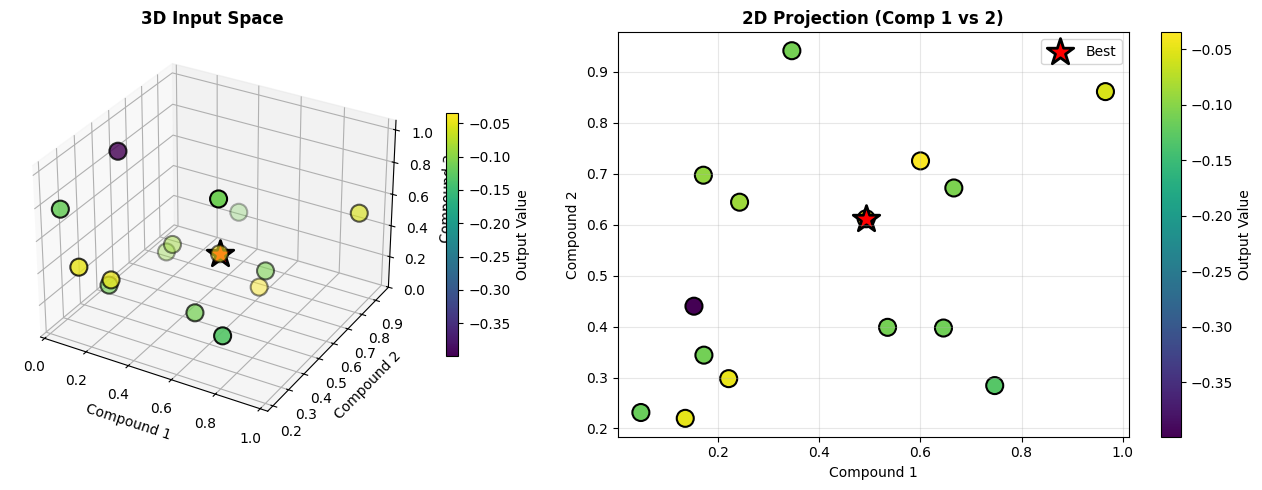

In [3]:
# Visualize initial data in 3D space
fig = plt.figure(figsize=(14, 5))

# 3D scatter plot
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(X_init[:, 0], X_init[:, 1], X_init[:, 2], c=y_init, s=150, cmap='viridis', edgecolors='black', linewidth=1.5)
best_idx = y_init.argmax()
ax1.scatter(X_init[best_idx, 0], X_init[best_idx, 1], X_init[best_idx, 2], s=400, c='red', marker='*', edgecolors='black', linewidth=2)
ax1.set_xlabel('Compound 1', fontsize=10)
ax1.set_ylabel('Compound 2', fontsize =10)
ax1.set_zlabel('Compound 3', fontsize=10)
ax1.set_title('3D Input Space', fontsize=12, fontweight='bold')
fig.colorbar(scatter, ax=ax1, label='Output Value', shrink=0.6)

# Pair plot (2D projections)
ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(X_init[:, 0], X_init[:, 1], c=y_init, s=150, cmap='viridis', edgecolors='black', linewidth=1.5)
ax2.scatter(X_init[best_idx, 0], X_init[best_idx, 1], s=400, c='red', marker='*', edgecolors='black', linewidth=2, label='Best')
ax2.set_xlabel('Compound 1', fontsize=10)
ax2.set_ylabel('Compound 2', fontsize=10)
ax2.set_title('2D Projection (Comp 1 vs 2)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Output Value')

plt.tight_layout()
plt.show()

### Step 3: Define Hyperparameters

**Hyperparameter Choices for 3D Drug Discovery:**

1. **Gaussian Process Kernel**: Matern 5/2  
   - Suitable for smooth drug response surfaces
   - Robust to local variations in efficacy

2. **Acquisition Function**: Expected Improvement
   - Balances exploring new compound combinations with exploiting known effective ones
   - 15 initial samples provides reasonable coverage of 3D space

3. **Restarts & Raw Samples**: 15 restarts, 1024 raw samples
   - Higher than 2D problems due to increased dimensionality
   - Ensures thorough search of acquisition landscape

4. **Input Bounds**: Determined from data with margin
   - Allows slight extrapolation beyond observed combinations

In [4]:
# Define hyperparameters
margin = 0.1
x_min = X_init.min(axis=0) - margin
x_max = X_init.max(axis=0) + margin
BOUNDS = torch.tensor([x_min, x_max], dtype=torch.float64)

NUM_RESTARTS = 15
RAW_SAMPLES = 1024

print("Hyperparameters:")
print(f"  Input dimensions: 3")
print(f"  Input bounds: \n{BOUNDS.numpy()}")
print(f"  Acquisition function: Expected Improvement (EI)")
print(f"  GP Kernel: Matern 5/2")
print(f"  Number of restarts: {NUM_RESTARTS}")
print(f"  Raw samples: {RAW_SAMPLES}")

Hyperparameters:
  Input dimensions: 3
  Input bounds: 
[[-0.05319105  0.11991724 -0.03391136]
 [ 1.06599485  1.04135983  1.09088187]]
  Acquisition function: Expected Improvement (EI)
  GP Kernel: Matern 5/2
  Number of restarts: 15
  Raw samples: 1024


### Step 4: Build Gaussian Process Surrogate Model

In [5]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Create and train Gaussian Process model
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)

print("\nTraining Gaussian Process model...")
fit_gpytorch_mll(mll)
print("✓ Model training complete!")

# Display learned hyperparameters
print("\nLearned GP Hyperparameters:")
print(f"  Noise variance: {gp_model.likelihood.noise.item():.6f}")
# Check if covar_module has outputscale (ScaleKernel) or is base kernel directly
if hasattr(gp_model.covar_module, 'outputscale'):
    print(f"  Output scale: {gp_model.covar_module.outputscale.item():.6f}")
    print(f"  Length scales: {gp_model.covar_module.base_kernel.lengthscale.detach().numpy()}")
else:
    # Direct access to kernel lengthscale
    print(f"  Length scales: {gp_model.covar_module.lengthscale.detach().numpy()}")

Training data shape: X=torch.Size([15, 3]), y=torch.Size([15, 1])

Training Gaussian Process model...
✓ Model training complete!

Learned GP Hyperparameters:
  Noise variance: 0.007039
  Length scales: [[2.32206568 1.11415541 0.05279214]]


### Step 5: Optimize Acquisition Function

In [6]:
# Create Expected Improvement acquisition function
best_f = y_train.max().item()
print(f"Best observed value: {best_f:.6f}")

EI = ExpectedImprovement(gp_model, best_f=best_f)

# Optimize acquisition function
print("\nOptimizing acquisition function...")
candidate, acq_value = optimize_acqf(
    EI,
    bounds=BOUNDS,
    q=1,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

next_point = candidate.detach().numpy()[0]
print("✓ Optimization complete!")
print(f"\nProposed next sample point:")
print(f"  X_next = {next_point}")
print(f"  Expected Improvement: {acq_value.item():.6f}")

Best observed value: -0.034835

Optimizing acquisition function...
✓ Optimization complete!

Proposed next sample point:
  X_next = [1.06599485 1.04135983 0.39618932]
  Expected Improvement: 0.019371


### Step 6: Visualize Results

For 3D problems, we visualize using multiple 2D projections and 3D scatter plots.

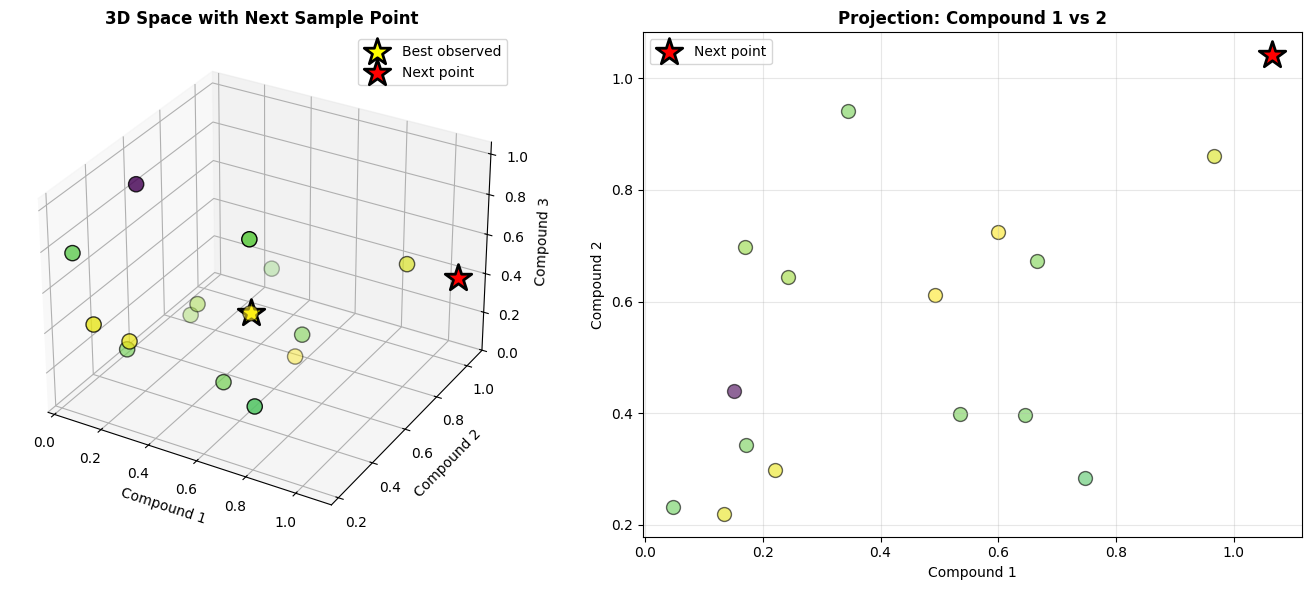

In [7]:
# Visualize data points and next candidate in 3D
fig = plt.figure(figsize=(14, 6))

# 3D plot with next point
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(X_init[:, 0], X_init[:, 1], X_init[:, 2], c=y_init, s=120, cmap='viridis', edgecolors='black', linewidth=1)
ax1.scatter(X_init[best_idx, 0], X_init[best_idx, 1], X_init[best_idx, 2], s=400, c='yellow', marker='*', edgecolors='black', linewidth=2, label='Best observed')
ax1.scatter(next_point[0], next_point[1], next_point[2], s=400, c='red', marker='*', edgecolors='black', linewidth=2, label='Next point')
ax1.set_xlabel('Compound 1')
ax1.set_ylabel('Compound 2')
ax1.set_zlabel('Compound 3')
ax1.set_title('3D Space with Next Sample Point', fontweight='bold')
ax1.legend()

# 2D projections showing all three pair plots
ax2 = fig.add_subplot(122)
colors = plt.cm.viridis((y_init - y_init.min()) / (y_init.max() - y_init.min()))
for i in range(len(X_init)):
    ax2.scatter(X_init[i, 0], X_init[i, 1], c=[colors[i]], s=100, edgecolors='black', linewidth=1, alpha=0.6)
ax2.scatter(next_point[0], next_point[1], s=400, c='red', marker='*', edgecolors='black', linewidth=2 , label='Next point')
ax2.set_xlabel('Compound 1')
ax2.set_ylabel('Compound 2')
ax2.set_title('Projection: Compound 1 vs 2', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

### Step 7: Track Optimization Progress

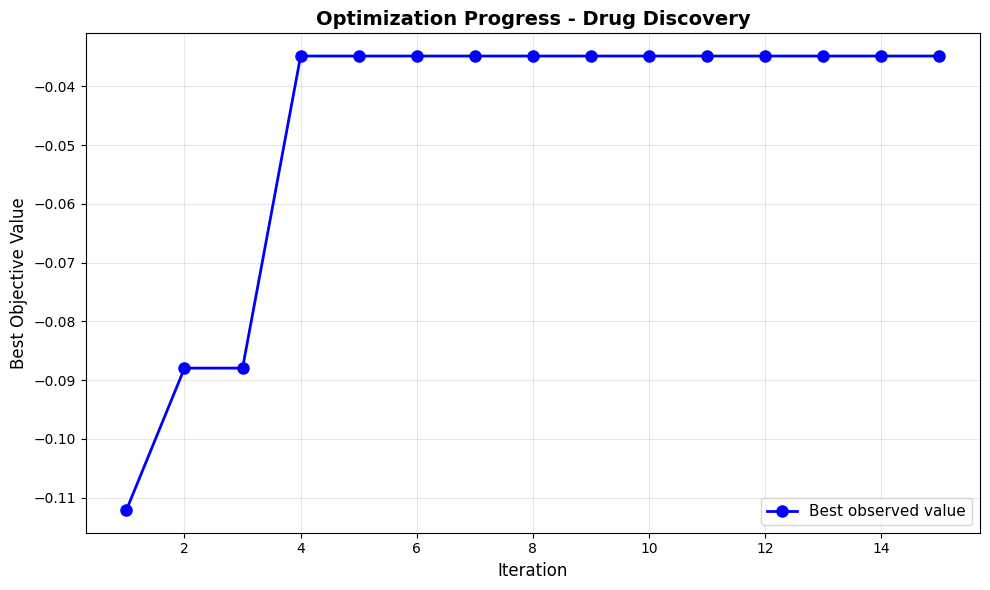

Starting best value: -0.034835
After 15 initial samples

Next submission: [1.06599485 1.04135983 0.39618932]


In [8]:
# Track best value over iterations
best_observed = np.maximum.accumulate(y_init)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_observed) + 1), best_observed, 'b-o', linewidth=2, markersize=8, label='Best observed value')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Objective Value', fontsize=12)
plt.title('Optimization Progress - Drug Discovery', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Starting best value: {y_init.max():.6f}")
print(f"After {len(y_init)} initial samples")
print(f"\nNext submission: {next_point}")

### Summary

**Initial Submission Complete - 3D Drug Discovery**

- Loaded 15 initial data points (3 compound combinations)
- Built GP surrogate model for 3D space
- Optimized Expected Improvement to find next compound combination
- Proposed next sample to minimize adverse reactions (maximize objective)
- Visualized using 3D scatter plots and 2D projections

**Next Steps:**
- Submit proposed compound combination
- Receive adverse reaction measurement
- Update dataset and retrain model